# Titanic Survival Prediction and Exploratory Analysis

This notebook presents an end-to-end classification workflow on the Titanic dataset. The work focuses on basic data cleaning, feature preprocessing, exploratory visualization, and evaluating multiple classification approaches using the processed passenger data.

**Main tasks covered**
- Handling missing values
- Encoding categorical features
- Selecting relevant variables
- Visualizing feature relationships
- Training and comparing Logistic Regression and SVM models
- Exploring K-Means clustering results


## 1. Libraries


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn import  svm
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn import metrics
from sklearn.metrics import mean_absolute_error



## 2. Data Loading and Initial Inspection


In [2]:
df=pd.read_csv('titanic.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [5]:
df['Ticket'].unique()

array(['A/5 21171', 'PC 17599', 'STON/O2. 3101282', '113803', '373450',
       '330877', '17463', '349909', '347742', '237736', 'PP 9549',
       '113783', 'A/5. 2151', '347082', '350406', '248706', '382652',
       '244373', '345763', '2649', '239865', '248698', '330923', '113788',
       '347077', '2631', '19950', '330959', '349216', 'PC 17601',
       'PC 17569', '335677', 'C.A. 24579', 'PC 17604', '113789', '2677',
       'A./5. 2152', '345764', '2651', '7546', '11668', '349253',
       'SC/Paris 2123', '330958', 'S.C./A.4. 23567', '370371', '14311',
       '2662', '349237', '3101295', 'A/4. 39886', 'PC 17572', '2926',
       '113509', '19947', 'C.A. 31026', '2697', 'C.A. 34651', 'CA 2144',
       '2669', '113572', '36973', '347088', 'PC 17605', '2661',
       'C.A. 29395', 'S.P. 3464', '3101281', '315151', 'C.A. 33111',
       'S.O.C. 14879', '2680', '1601', '348123', '349208', '374746',
       '248738', '364516', '345767', '345779', '330932', '113059',
       'SO/C 14885', '31012

In [6]:
df['Sex'].unique()

array(['male', 'female'], dtype=object)

In [7]:
df['Embarked'].unique()

array(['S', 'C', 'Q', nan], dtype=object)

## 3. Data Cleaning and Preprocessing


In [8]:
#droping data that is we will not used
df.drop(['PassengerId','Ticket','Cabin'],axis=1,inplace=True)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    object 
 3   Sex       891 non-null    object 
 4   Age       714 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Fare      891 non-null    float64
 8   Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(3)
memory usage: 62.8+ KB


In [10]:
#filling the age values
df['Age'].fillna(df['Age'].median(),inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0],inplace=True)

/tmp/ipython-input-2334704583.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(),inplace=True)
/tmp/ipython-input-2334704583.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try u

In [11]:
#mapping
df['Sex']=df['Sex'].map({'male':0,'female':1})
df['Embarked']=df['Embarked'].map({'S':0,'C':1,'Q':2})

In [12]:
df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,7.2500,0
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,71.2833,1
2,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,7.9250,0
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,53.1000,0
4,0,3,"Allen, Mr. William Henry",0,35.0,0,0,8.0500,0


In [13]:
df.drop('Name',axis=1,inplace=True)

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    int64  
 3   Age       891 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Embarked  891 non-null    int64  
dtypes: float64(2), int64(6)
memory usage: 55.8 KB


## 4. Exploratory Analysis


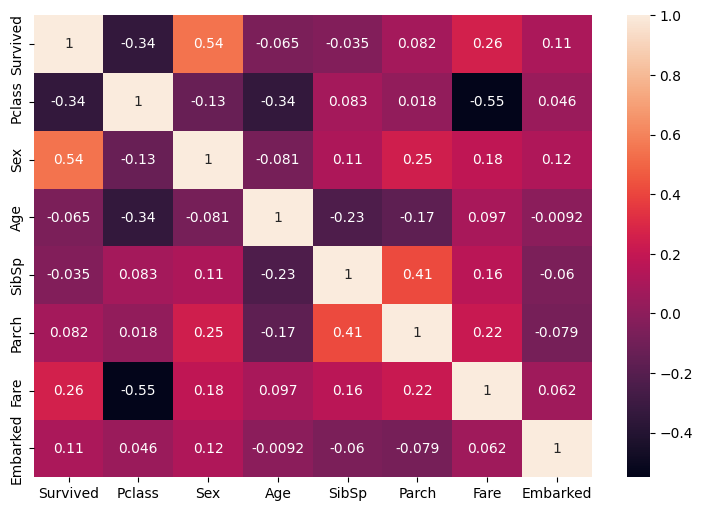

In [15]:
plt.figure(figsize=(9,6))
sns.heatmap(df.corr(numeric_only=True),annot=True)
plt.show()

In [16]:
df.drop('SibSp',axis=1,inplace=True)

In [17]:
df.head()

,Survived,Pclass,Sex,Age,Parch,Fare,Embarked
0,0,3,0,22.0,0,7.2500,0
1,1,1,1,38.0,0,71.2833,1
2,1,3,1,26.0,0,7.9250,0
3,1,1,1,35.0,0,53.1000,0
4,0,3,0,35.0,0,8.0500,0


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    int64  
 3   Age       891 non-null    float64
 4   Parch     891 non-null    int64  
 5   Fare      891 non-null    float64
 6   Embarked  891 non-null    int64  
dtypes: float64(2), int64(5)
memory usage: 48.9 KB


## 5. Feature Selection and Train/Test Split


In [19]:
x=df.drop('Survived',axis=1)
y=df['Survived']

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

## 6. Logistic Regression


In [20]:
LR=LogisticRegression()
LR.fit(x_train,y_train)

LogisticRegression()

In [21]:
y_LR=LR.predict(x_test)
print(accuracy_score(y_test,y_LR))
print(classification_report(y_test,y_LR))

0.7988826815642458
              precision    recall  f1-score   support

           0       0.82      0.85      0.83       105
           1       0.77      0.73      0.75        74

    accuracy                           0.80       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



## 7. Support Vector Machine Models


In [22]:
sv=svm.SVC(kernel='linear')
sv.fit(x_train,y_train)

SVC(kernel='linear')

In [23]:
y_sv=sv.predict(x_test)
print(accuracy_score(y_test,y_sv))
print(classification_report(y_test,y_sv))

0.7821229050279329
              precision    recall  f1-score   support

           0       0.80      0.84      0.82       105
           1       0.75      0.70      0.73        74

    accuracy                           0.78       179
   macro avg       0.78      0.77      0.77       179
weighted avg       0.78      0.78      0.78       179



In [24]:
rbf=svm.SVC(kernel='rbf',gamma=0.01)
rbf.fit(x_train,y_train)

SVC(gamma=0.01)

In [25]:
y_rbf=rbf.predict(x_test)
print(accuracy_score(y_test,y_rbf))
print(classification_report(y_test,y_rbf))

0.7262569832402235
              precision    recall  f1-score   support

           0       0.70      0.94      0.80       105
           1       0.84      0.42      0.56        74

    accuracy                           0.73       179
   macro avg       0.77      0.68      0.68       179
weighted avg       0.76      0.73      0.70       179



In [34]:
poly=svm.SVC(kernel='poly',degree=1)
poly.fit(x_train,y_train)

SVC(degree=1, kernel='poly')

In [35]:


y_poly=poly.predict(x_test)
print(accuracy_score(y_test,y_poly))
print(classification_report(y_test,y_poly))

0.6480446927374302
              precision    recall  f1-score   support

           0       0.63      0.97      0.76       105
           1       0.82      0.19      0.31        74

    accuracy                           0.65       179
   macro avg       0.73      0.58      0.54       179
weighted avg       0.71      0.65      0.58       179



In [28]:
sigmoid=svm.SVC(kernel='sigmoid')
sigmoid.fit(x_train,y_train)

SVC(kernel='sigmoid')

In [29]:
y_sigmoid=sigmoid.predict(x_test)
print(accuracy_score(y_test,y_sigmoid))
print(classification_report(y_test,y_sigmoid))


0.6145251396648045
              precision    recall  f1-score   support

           0       0.66      0.70      0.68       105
           1       0.54      0.50      0.52        74

    accuracy                           0.61       179
   macro avg       0.60      0.60      0.60       179
weighted avg       0.61      0.61      0.61       179



## 8. K-Means Clustering


In [37]:
scaler=StandardScaler()
x_scaled=scaler.fit_transform(x)

In [38]:
kmeans=KMeans(n_clusters=2,random_state=42)
clusters=kmeans.fit_predict(x_scaled)
df['clusters']=clusters

In [39]:
df.head()

,Survived,Pclass,Sex,Age,Parch,Fare,Embarked,clusters
0,0,3,0,22.0,0,7.2500,0,0
1,1,1,1,38.0,0,71.2833,1,1
2,1,3,1,26.0,0,7.9250,0,0
3,1,1,1,35.0,0,53.1000,0,1
4,0,3,0,35.0,0,8.0500,0,0


In [40]:
pd.crosstab(df['Survived'],df['clusters'])

clusters,0,1
Survived,,
0,448,101
1,188,154


## 9. Summary

This notebook applies a complete introductory ML workflow to the Titanic dataset.  
The saved results show that **Logistic Regression achieved about 80% test accuracy**, making it the strongest classifier among the tested models in this notebook.
